In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
path = './Dataset'
label_list = []
for dir in os.listdir(path):
    label_list.append(dir)

images = []
classes = []
for i, label in enumerate(label_list):
    full_path = os.path.join(path, label)
    for j, image in enumerate(os.listdir(full_path)):
        img_path = os.path.join(full_path, image)
        img = load_img(img_path)
        img = img_to_array(img)
        img = tf.image.rgb_to_grayscale(img)
        img = img / 255

        images.append(img)
        classes.append(i)

In [5]:
y = tf.keras.utils.to_categorical(classes, len(label_list))
images = np.asarray(images)

In [6]:
x_train, x_temp, y_train, y_temp = train_test_split(images, y, train_size=0.8, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, train_size=0.8, random_state=42)

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same', input_shape=(224, 224, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(16, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same'),
    tf.keras.layers.Conv2D(16, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax'),
])

c:\Github\deep-learning\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    callbacks=early_stopping
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5156 - loss: 1.0608 - val_accuracy: 0.8125 - val_loss: 0.6603
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8250 - loss: 0.5056 - val_accuracy: 0.7375 - val_loss: 0.6681
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8850 - loss: 0.3282 - val_accuracy: 0.8500 - val_loss: 0.4718
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9206 - loss: 0.2313 - val_accuracy: 0.8625 - val_loss: 0.4540
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9519 - loss: 0.1434 - val_accuracy: 0.8375 - val_loss: 0.5220
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9675 - loss: 0.1055 - val_accuracy: 0.8500 - val_loss: 0.5503
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9775 - loss: 0.0664 - val_accuracy: 0.8375 - val_loss: 0.5764


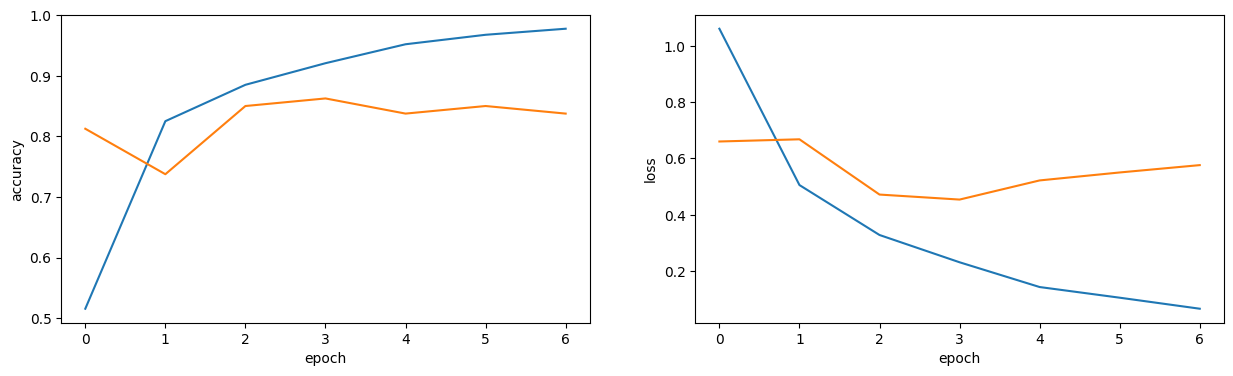

In [11]:
plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()

In [14]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f'loss: {loss}')
print(f'accuracy: {accuracy}')

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_pred, target_names=label_list))

10/10 - 0s - 18ms/step - accuracy: 0.8531 - loss: 0.4756
loss: 0.4756384491920471
accuracy: 0.8531249761581421
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

    Broccoli       0.77      0.96      0.86        80
      Carrot       0.93      0.92      0.93        74
    Cucumber       0.90      0.82      0.86        73
      Tomato       0.85      0.73      0.79        93

    accuracy                           0.85       320
   macro avg       0.86      0.86      0.86       320
weighted avg       0.86      0.85      0.85       320

